In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [85]:
cirr = pd.read_csv('/content/cirrhosis.csv')

In [86]:
# 1. Статистическая информация о наборе данных
print("="*60)
print("ОСНОВНАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("="*60)
print(f"Размер датасета: {cirr.shape[0]} строк × {cirr.shape[1]} столбцов")
print(f"\nКоличество пропущенных значений:")
print(cirr.isnull().sum())


ОСНОВНАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ
Размер датасета: 418 строк × 20 столбцов

Количество пропущенных значений:
ID                 0
N_Days             0
Status             0
Drug             106
Age                0
Sex                0
Ascites          106
Hepatomegaly     106
Spiders          106
Edema              0
Bilirubin          0
Cholesterol      134
Albumin            0
Copper           108
Alk_Phos         106
SGOT             106
Tryglicerides    136
Platelets         11
Prothrombin        2
Stage              6
dtype: int64


In [87]:
print("\n" + "="*60)
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА ЧИСЛОВЫХ ПРИЗНАКОВ")
print("="*60)
print(cirr.describe())


ОПИСАТЕЛЬНАЯ СТАТИСТИКА ЧИСЛОВЫХ ПРИЗНАКОВ
               ID       N_Days           Age   Bilirubin  Cholesterol  \
count  418.000000   418.000000    418.000000  418.000000   284.000000   
mean   209.500000  1917.782297  18533.351675    3.220813   369.510563   
std    120.810458  1104.672992   3815.845055    4.407506   231.944545   
min      1.000000    41.000000   9598.000000    0.300000   120.000000   
25%    105.250000  1092.750000  15644.500000    0.800000   249.500000   
50%    209.500000  1730.000000  18628.000000    1.400000   309.500000   
75%    313.750000  2613.500000  21272.500000    3.400000   400.000000   
max    418.000000  4795.000000  28650.000000   28.000000  1775.000000   

          Albumin      Copper      Alk_Phos        SGOT  Tryglicerides  \
count  418.000000  310.000000    312.000000  312.000000     282.000000   
mean     3.497440   97.648387   1982.655769  122.556346     124.702128   
std      0.424972   85.613920   2140.388824   56.699525      65.148639   
mi

In [88]:
# 2. Названия столбцов и первые строки
print("\n" + "="*60)
print("НАЗВАНИЯ СТОЛБЦОВ")
print("="*60)
print(cirr.columns.tolist())

print("\n" + "="*60)
print("ПЕРВЫЕ 5 СТРОК ДАТАСЕТА")
print("="*60)
print(cirr.head())



НАЗВАНИЯ СТОЛБЦОВ
['ID', 'N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']

ПЕРВЫЕ 5 СТРОК ДАТАСЕТА
   ID  N_Days Status             Drug    Age Sex Ascites Hepatomegaly Spiders  \
0   1     400      D  D-penicillamine  21464   F       Y            Y       Y   
1   2    4500      C  D-penicillamine  20617   F       N            Y       Y   
2   3    1012      D  D-penicillamine  25594   M       N            N       N   
3   4    1925      D  D-penicillamine  19994   F       N            Y       Y   
4   5    1504     CL          Placebo  13918   F       N            Y       Y   

  Edema  Bilirubin  Cholesterol  Albumin  Copper  Alk_Phos    SGOT  \
0     Y       14.5        261.0     2.60   156.0    1718.0  137.95   
1     N        1.1        302.0     4.14    54.0    7394.8  113.52   
2     S        1.4        176.0     3.48

In [89]:
# 3. Статистика категориальных признаков
print("\n" + "="*60)
print("СТАТИСТИКА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("="*60)
print(cirr.describe(include=['object']))


СТАТИСТИКА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
       Status             Drug  Sex Ascites Hepatomegaly Spiders Edema
count     418              312  418     312          312     312   418
unique      3                2    2       2            2       2     3
top         C  D-penicillamine    F       N            Y       N     N
freq      232              158  374     288          160     222   354


In [90]:
# 4. Замена категориальных данных количественными
print("\n" + "="*60)
print("КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("="*60)
cirr_coded = cirr.copy()



КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ


In [91]:
# Кодирование статуса
cirr_coded['Status'] = cirr_coded['Status'].map({'C': 0, 'CL': 1, 'D': 2})
print("Status: C=0 (цензурировано), CL=1 (трансплантация), D=2 (умер)")

# Кодирование пола
cirr_coded['Sex'] = cirr_coded['Sex'].map({'M': 0, 'F': 1})
print("Sex: M=0 (мужской), F=1 (женский)")

# Кодирование препарата
cirr_coded['Drug'] = cirr_coded['Drug'].map({'Placebo': 0, 'D-penicillamine': 1})
print("Drug: Placebo=0, D-penicillamine=1")

# Кодирование клинических симптомов
for col in ['Ascites', 'Hepatomegaly', 'Spiders']:
    cirr_coded[col] = cirr_coded[col].map({'N': 0, 'Y': 1, 'S': 0.5})
    print(f"{col}: N=0 (нет), Y=1 (да), S=0.5 (умеренно)")

# Кодирование отеков
cirr_coded['Edema'] = cirr_coded['Edema'].map({'N': 0, 'S': 0.5, 'Y': 1})
print("Edema: N=0 (нет), S=0.5 (умеренно), Y=1 (да)")

# Проверка результата кодирования
print("\nПервые 5 строк после кодирования:")
print(cirr_coded.head())



Status: C=0 (цензурировано), CL=1 (трансплантация), D=2 (умер)
Sex: M=0 (мужской), F=1 (женский)
Drug: Placebo=0, D-penicillamine=1
Ascites: N=0 (нет), Y=1 (да), S=0.5 (умеренно)
Hepatomegaly: N=0 (нет), Y=1 (да), S=0.5 (умеренно)
Spiders: N=0 (нет), Y=1 (да), S=0.5 (умеренно)
Edema: N=0 (нет), S=0.5 (умеренно), Y=1 (да)

Первые 5 строк после кодирования:
   ID  N_Days  Status  Drug    Age  Sex  Ascites  Hepatomegaly  Spiders  \
0   1     400       2   1.0  21464    1      1.0           1.0      1.0   
1   2    4500       0   1.0  20617    1      0.0           1.0      1.0   
2   3    1012       2   1.0  25594    0      0.0           0.0      0.0   
3   4    1925       2   1.0  19994    1      0.0           1.0      1.0   
4   5    1504       1   0.0  13918    1      0.0           1.0      1.0   

   Edema  Bilirubin  Cholesterol  Albumin  Copper  Alk_Phos    SGOT  \
0    1.0       14.5        261.0     2.60   156.0    1718.0  137.95   
1    0.0        1.1        302.0     4.14    54.0

In [92]:
# 5. Визуализация данных



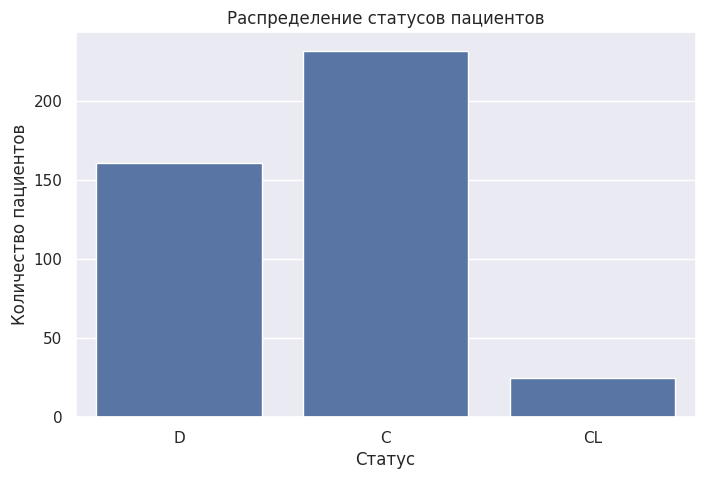

In [93]:
# Визуализация 1: Распределение статусов пациентов
plt.figure(figsize=(8, 5))
sns.countplot(data=cirr, x='Status')
plt.title('Распределение статусов пациентов')
plt.xlabel('Статус')
plt.ylabel('Количество пациентов')
plt.show()

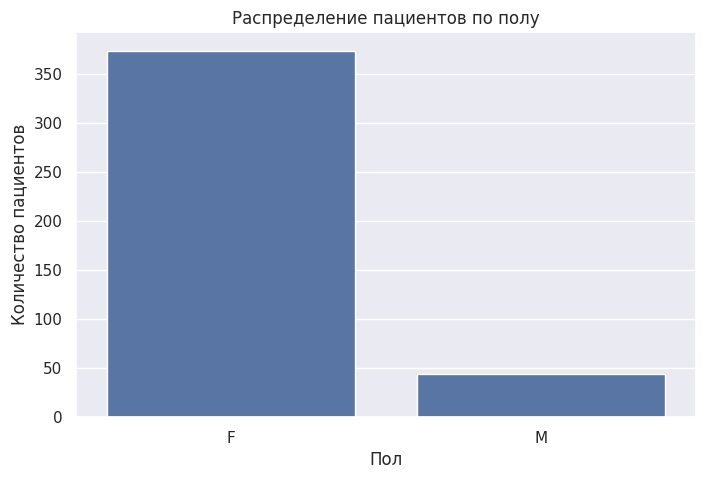

In [94]:
# Визуализация 2: Распределение по полу
plt.figure(figsize=(8, 5))
sns.countplot(data=cirr, x='Sex')
plt.title('Распределение пациентов по полу')
plt.xlabel('Пол')
plt.ylabel('Количество пациентов')
plt.show()


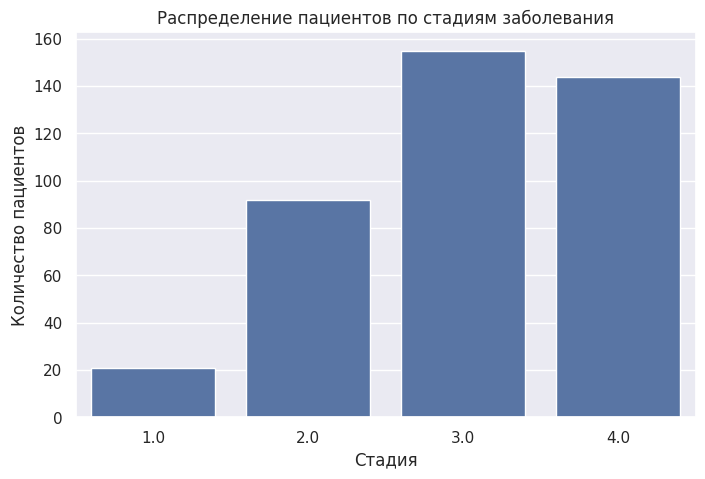

In [95]:
# Визуализация 3: Распределение по классам стадий заболевания
plt.figure(figsize=(8, 5))
sns.countplot(data=cirr, x='Stage')
plt.title('Распределение пациентов по стадиям заболевания')
plt.xlabel('Стадия')
plt.ylabel('Количество пациентов')
plt.show()

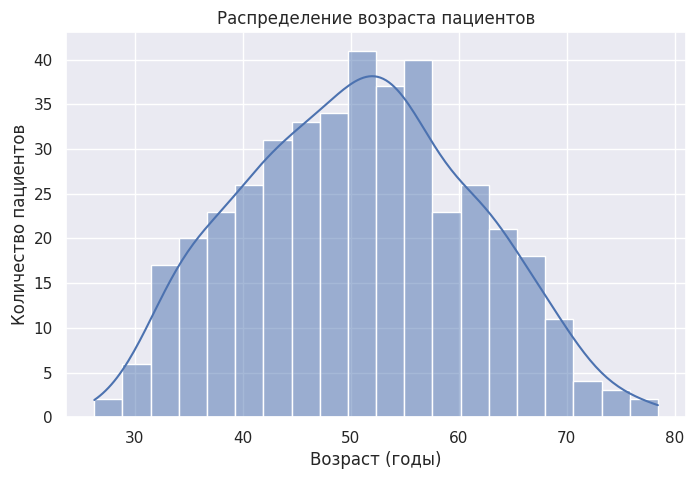

In [96]:
# Визуализация 4: Распределение возраста
plt.figure(figsize=(8, 5))
cirr['Age_Years'] = cirr['Age'] / 365.25  # Конвертация дней в годы
sns.histplot(data=cirr, x='Age_Years', bins=20, kde=True)
plt.title('Распределение возраста пациентов')
plt.xlabel('Возраст (годы)')
plt.ylabel('Количество пациентов')
plt.show()

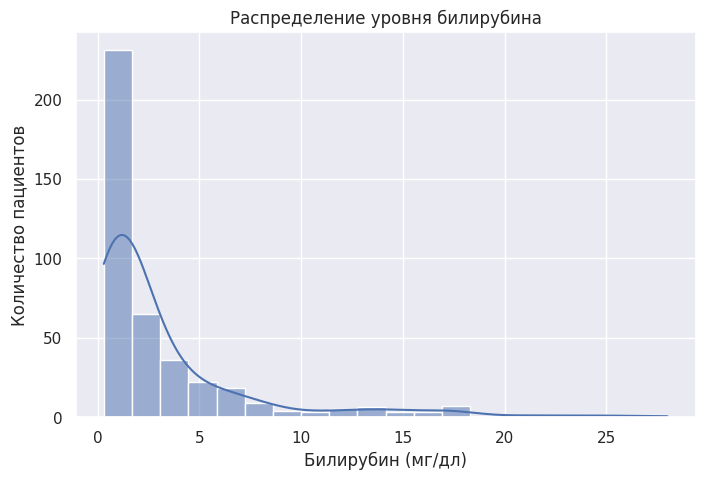

In [97]:
# Визуализация 5: Распределение билирубина
plt.figure(figsize=(8, 5))
sns.histplot(data=cirr, x='Bilirubin', bins=20, kde=True)
plt.title('Распределение уровня билирубина')
plt.xlabel('Билирубин (мг/дл)')
plt.ylabel('Количество пациентов')
plt.show()

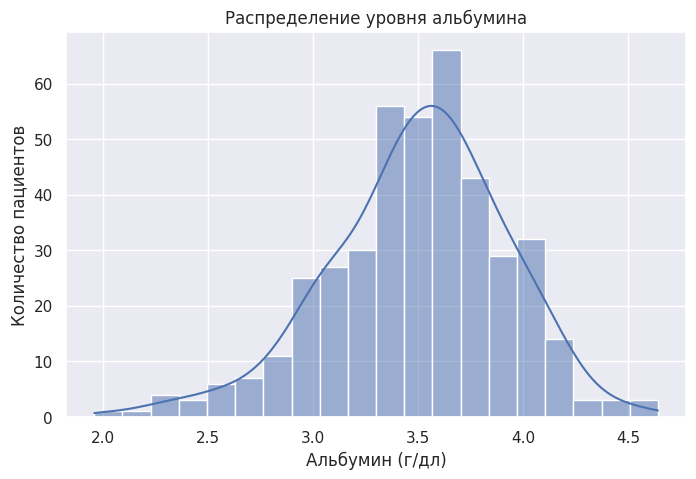

In [98]:
# Визуализация 6: Распределение альбумина
plt.figure(figsize=(8, 5))
sns.histplot(data=cirr, x='Albumin', bins=20, kde=True)
plt.title('Распределение уровня альбумина')
plt.xlabel('Альбумин (г/дл)')
plt.ylabel('Количество пациентов')
plt.show()


In [99]:
# 6. Групповые визуализации

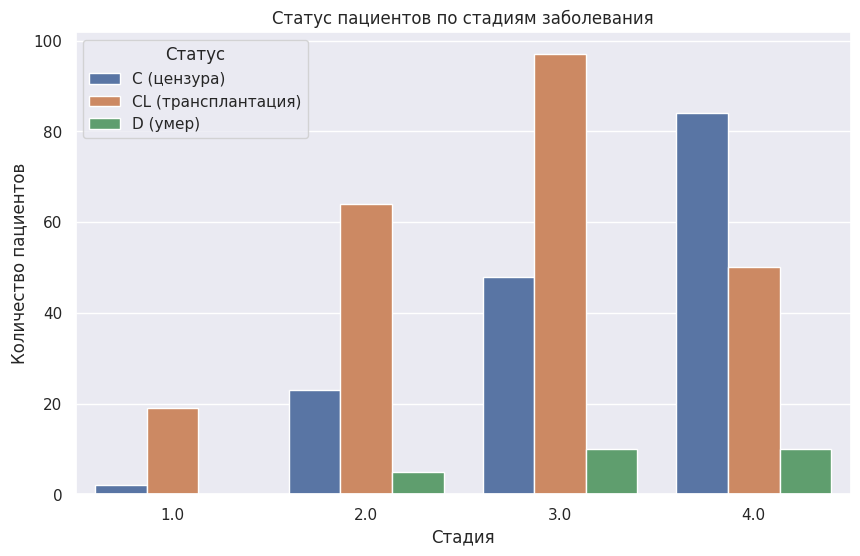

In [100]:
# Групповая визуализация 1: Статус по стадиям заболевания
plt.figure(figsize=(10, 6))
sns.countplot(data=cirr, x='Stage', hue='Status')
plt.title('Статус пациентов по стадиям заболевания')
plt.xlabel('Стадия')
plt.ylabel('Количество пациентов')
plt.legend(title='Статус', labels=['C (цензура)', 'CL (трансплантация)', 'D (умер)'])
plt.show()

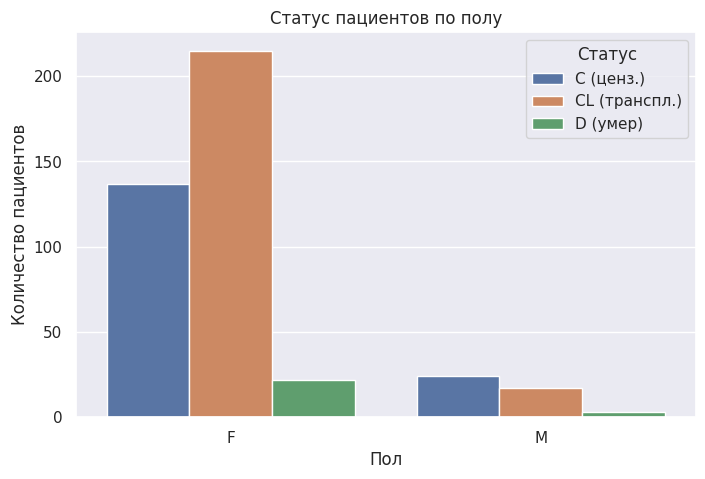

In [101]:
# Групповая визуализация 2: Статус по полу
plt.figure(figsize=(8, 5))
sns.countplot(data=cirr, x='Sex', hue='Status')
plt.title('Статус пациентов по полу')
plt.xlabel('Пол')
plt.ylabel('Количество пациентов')
plt.legend(title='Статус', labels=['C (ценз.)', 'CL (транспл.)', 'D (умер)'])
plt.show()

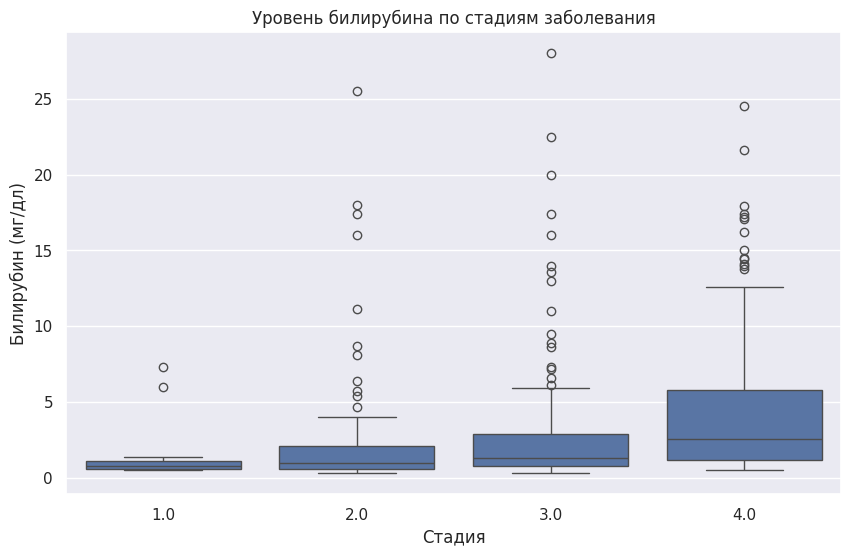

In [102]:
# Групповая визуализация 3: Билирубин по стадиям заболевания
plt.figure(figsize=(10, 6))
sns.boxplot(data=cirr, x='Stage', y='Bilirubin')
plt.title('Уровень билирубина по стадиям заболевания')
plt.xlabel('Стадия')
plt.ylabel('Билирубин (мг/дл)')
plt.show()

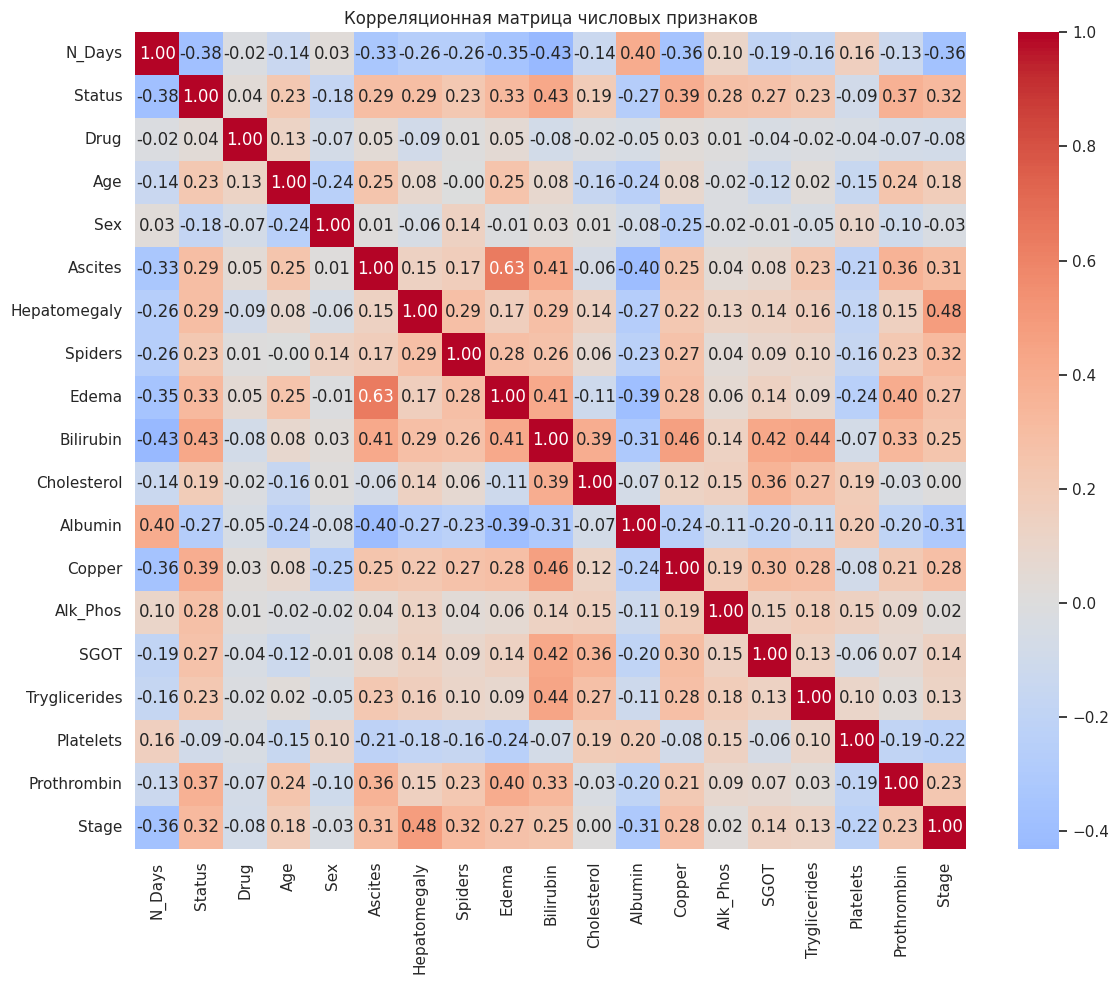

In [103]:
# 7. Корреляционная матрица числовых признаков
plt.figure(figsize=(12, 10))
numeric_cirr = cirr_coded.select_dtypes(include=[np.number]).drop(['ID'], axis=1).dropna()
correlation_matrix = numeric_cirr.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()
